# Results Visualisation

This notebook rebuilds the contrastive pairs from the prediction log and
manifest, then plots the pilot sign-agreement check and the stratified
directional analysis. Definitions match Notebook 04: the primary stratum is
`referent_selection` with `feasible_both == 'yes'` on the initial frame; the
headline statistic is the paired lateral difference `dx_A - dx_B` with a
Wilcoxon signed-rank test; the sign-flip rate is descriptive only.

The model is never loaded here. Inputs are the CSVs from Notebooks 02 and 03.
Figures are written under the Drive cache as PNGs for reporting. Isaac Sim
arrow figures and rollout videos remain a separate rendering stage.


## 1. Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
PRED_CSV = '/content/drive/MyDrive/openvla_cache/probe_predictions_v3.csv'
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/bridge_multiobj'
MANIFEST_CSV = os.path.join(CACHE_DIR, 'manifest.csv')
FIGS_DIR = '/content/drive/MyDrive/openvla_cache/results_figs'
os.makedirs(FIGS_DIR, exist_ok=True)
print('predictions ->', PRED_CSV)
print('manifest    ->', MANIFEST_CSV)
print('figures     ->', FIGS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
predictions -> /content/drive/MyDrive/openvla_cache/probe_predictions_v3.csv
manifest    -> /content/drive/MyDrive/openvla_cache/bridge_multiobj/manifest.csv
figures     -> /content/drive/MyDrive/openvla_cache/results_figs


## 2. Import `export_pairs.py`

Imports pair assembly helpers from the Drive-synced repository. Mount Drive in
section 1 first. The default path is `/content/drive/Othercomputers/My MacBook Pro/ECS8056`; change
`REPO_DIR` in the next cell if the folder lives elsewhere on Drive.


In [2]:
import sys, os, importlib

# Drive-synced repository (mount Drive first). Change if the folder path differs.
REPO_DIR = '/content/drive/Othercomputers/My MacBook Pro/ECS8056'


def find_repo_dir(anchor):
    """Return the directory holding `anchor` from known Drive paths only."""
    candidates = []
    if REPO_DIR:
        candidates.append(REPO_DIR)
    candidates.extend([
        '/content/drive/Othercomputers/My MacBook Pro/ECS8056',
        '/content/drive/MyDrive/ECS8056',
        '/content/ECS8056',
    ])
    seen = set()
    for d in candidates:
        d = os.path.abspath(d)
        if d in seen:
            continue
        seen.add(d)
        if os.path.isfile(os.path.join(d, anchor)):
            return d
    return None


module_dir = find_repo_dir('export_pairs.py')
if module_dir is None:
    raise FileNotFoundError(
        f"export_pairs.py not found on Google Drive. Mount Drive in section 1, "
        f"confirm ECS8056 has finished syncing, then set REPO_DIR to the folder "
        f"that contains export_pairs.py (tried REPO_DIR={REPO_DIR!r}). Also check with:\n"
        f"  !ls /content/drive/Othercomputers/My MacBook Pro/ECS8056")
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
sys.modules.pop('export_pairs', None)
importlib.invalidate_caches()

import export_pairs
from export_pairs import load_inputs, build_pairs
print('imported export_pairs.py from', module_dir)
print('BRIDGE_TO_ISAAC =\n', export_pairs.BRIDGE_TO_ISAAC)


imported export_pairs.py from /content/drive/Othercomputers/My MacBook Pro/ECS8056
BRIDGE_TO_ISAAC =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 3. Load the prediction log and manifest

`load_inputs` validates that the prediction log carries the required probe
columns and fails loudly if any are missing.


In [3]:
preds, manifest = load_inputs(PRED_CSV, MANIFEST_CSV)
print(f'{len(preds)} logged predictions | {preds["pair_id"].nunique()} pair ids | '
      f'{preds["scene_id"].nunique()} scenes')
print('predictions per frame:', dict(preds['frame'].value_counts()))
print(f'{len(manifest)} manifest rows')
preds.head(4)


2226 logged predictions | 797 pair ids | 791 scenes
predictions per frame: {'initial': np.int64(1594), 'grasp': np.int64(632)}
2239 manifest rows


,timestamp,instruction,unnorm_key,do_sample,gpu_name,gpu_capability,dtype,seed,torch,transformers,...,a5,a6,scene_id,pair_id,role,frame,spatial_term,category,feasible_both,sample_idx
0,2026-07-26T13:23:22.837563+00:00,Place the can to the left of the pot.,bridge_orig,False,NVIDIA A100-SXM4-80GB,sm_80,bfloat16,42,2.11.0+cu128,4.40.1,...,0.007992,0.996078,0,ep000000_left,a,initial,left,placement_relation,yes,0
1,2026-07-26T13:23:23.444073+00:00,Place the can to the right of the pot.,bridge_orig,False,NVIDIA A100-SXM4-80GB,sm_80,bfloat16,42,2.11.0+cu128,4.40.1,...,-0.009737,0.996078,0,ep000000_left,b,initial,left,placement_relation,yes,0
2,2026-07-26T13:23:24.078268+00:00,Slide the cloth diagonally to the front of the...,bridge_orig,False,NVIDIA A100-SXM4-80GB,sm_80,bfloat16,42,2.11.0+cu128,4.40.1,...,-0.008126,0.996078,2,ep000002_front,a,initial,front,referent_selection,no,0
3,2026-07-26T13:23:24.683984+00:00,Slide the cloth diagonally to the back of the ...,bridge_orig,False,NVIDIA A100-SXM4-80GB,sm_80,bfloat16,42,2.11.0+cu128,4.40.1,...,0.001545,0.996078,2,ep000002_front,b,initial,front,referent_selection,no,0


## 4. Build contrastive pairs

Predictions are grouped by `(pair_id, frame)`. Groups lacking both roles are
reported and skipped. A `placement_relation` pair_id may appear twice, once per
frame, when both were probed.


In [4]:
from collections import Counter

pairs, skipped = build_pairs(preds, manifest)
with_gt = sum(1 for p in pairs if 'gt_vector' in p)
print(f'{len(pairs)} complete pairs | {skipped} incomplete (pair_id, frame) groups skipped | '
      f'{with_gt} pairs joined to ground truth')
print('pairs per (category, frame):',
      dict(Counter((p.get('category', 'other'), p['frame']) for p in pairs)))


1113 complete pairs | 0 incomplete (pair_id, frame) groups skipped | 1108 pairs joined to ground truth
pairs per (category, frame): {('placement_relation', 'initial'): 409, ('referent_selection', 'initial'): 388, ('placement_relation', 'grasp'): 316}


## 5. Analysis tables

Builds the pilot sign-agreement table and the per-pair lateral-difference table
used by every plot below. Stratum definitions match Notebook 04.


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

MIN_GT_NORM = 0.01
LATERAL_AXIS = 0  # dx: the translation component expected to flip for left/right

# --- Pilot: sign agreement on the dominant ground-truth axis ---
pilot_rows = []
for p in pairs:
    gt = p.get('gt_vector')
    if gt is None:
        continue
    gt_t = np.asarray(gt[:3], dtype=float)
    if np.linalg.norm(gt_t) < MIN_GT_NORM:
        continue
    dom = int(np.argmax(np.abs(gt_t)))
    for role in ('a', 'b'):
        act_t = np.asarray(p[f'action_{role}'][:3], dtype=float)
        pilot_rows.append({
            'pair_id': p['pair_id'],
            'frame': p['frame'],
            'role': role,
            'dominant_axis': 'xyz'[dom],
            'gt_sign': float(np.sign(gt_t[dom])),
            'pred_sign': float(np.sign(act_t[dom])),
            'agree': bool(np.sign(act_t[dom]) == np.sign(gt_t[dom])),
        })
pilot = pd.DataFrame(pilot_rows)

# --- Per-pair lateral difference ---
rec = []
pair_lookup = {}
for p in pairs:
    a = float(p['action_a'][LATERAL_AXIS])
    b = float(p['action_b'][LATERAL_AXIS])
    key = (p['pair_id'], p['frame'])
    pair_lookup[key] = p
    rec.append({
        'pair_id': p['pair_id'],
        'frame': p['frame'],
        'category': p.get('category', 'other'),
        'feasible_both': p.get('feasible_both', 'unreviewed'),
        'spatial_term': p.get('spatial_term', ''),
        'lat_a': a,
        'lat_b': b,
        'diff': a - b,
        'sign_flip': (a * b) < 0,
    })
df = pd.DataFrame(rec)


def stratum_mask(name):
    """Boolean mask for a named analysis stratum."""
    if name == 'primary_referent':
        return ((df['category'] == 'referent_selection')
                & (df['feasible_both'] == 'yes')
                & (df['frame'] == 'initial'))
    if name == 'placement_grasp':
        return (df['category'] == 'placement_relation') & (df['frame'] == 'grasp')
    if name == 'placement_initial':
        return (df['category'] == 'placement_relation') & (df['frame'] == 'initial')
    if name == 'referent_other':
        return ((df['category'] == 'referent_selection')
                & (df['feasible_both'] != 'yes'))
    if name == 'other':
        return df['category'] == 'other'
    raise KeyError(name)


STRATA = [
    ('primary_referent', 'referent_selection & feasible (initial)'),
    ('placement_grasp', 'placement_relation (grasp)'),
    ('placement_initial', 'placement_relation (initial, expected null)'),
    ('referent_other', 'referent_selection infeasible/unreviewed'),
    ('other', 'other'),
]


def summarise_row(sub, label, key):
    n = len(sub)
    row = {
        'stratum_key': key,
        'stratum': label,
        'n': n,
        'sign_flip_rate': np.nan,
        'W': np.nan,
        'p': np.nan,
        'median_diff': np.nan,
    }
    if n == 0:
        return row
    row['sign_flip_rate'] = float(sub['sign_flip'].mean())
    diffs = sub['diff'].to_numpy()
    row['median_diff'] = float(np.median(diffs))
    if n >= 1 and np.any(diffs != 0):
        try:
            stat, pval = wilcoxon(diffs)
            row['W'] = float(stat)
            row['p'] = float(pval)
        except ValueError:
            pass
    return row


summary = pd.DataFrame([
    summarise_row(df[stratum_mask(k)], label, k) for k, label in STRATA
])
display(summary)
print('\nstratum sizes:')
print(df.groupby(['category', 'frame', 'feasible_both']).size())
if len(pilot):
    print('\npilot overall sign agreement: '
          f"{pilot['agree'].mean():.1%} over {len(pilot)} predictions")


,stratum_key,stratum,n,sign_flip_rate,W,p,median_diff
0,primary_referent,referent_selection & feasible (initial),7,0.000000,5.0,1.000000,0.0
1,placement_grasp,placement_relation (grasp),316,0.246835,9606.5,0.263441,0.0
2,placement_initial,"placement_relation (initial, expected null)",409,0.149144,9656.0,0.002430,0.0
3,referent_other,referent_selection infeasible/unreviewed,381,0.230971,12496.5,0.375289,0.0
4,other,other,0,NaN,NaN,NaN,NaN



stratum sizes:
category            frame    feasible_both
placement_relation  grasp    no                 8
                             unreviewed       286
                             yes               22
                    initial  no                21
                             unreviewed       341
                             yes               47
referent_selection  initial  no                 4
                             unreviewed       377
                             yes                7
dtype: int64

pilot overall sign agreement: 59.6% over 2212 predictions


## 6. Inventory: stratum sizes

Pair counts by category, observation frame, and feasibility label.


wrote /content/drive/MyDrive/openvla_cache/results_figs/01_inventory_stratum_sizes.png


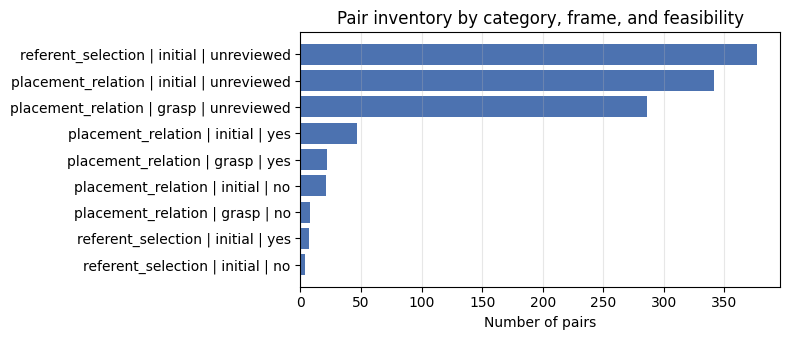

In [6]:
import matplotlib.pyplot as plt

size_tbl = (df.groupby(['category', 'frame', 'feasible_both'])
              .size()
              .reset_index(name='n')
              .sort_values('n', ascending=True))
size_tbl['label'] = (size_tbl['category'] + ' | ' + size_tbl['frame']
                     + ' | ' + size_tbl['feasible_both'].astype(str))

fig, ax = plt.subplots(figsize=(8, max(3.5, 0.35 * len(size_tbl))))
ax.barh(size_tbl['label'], size_tbl['n'], color='#4C72B0')
ax.set_xlabel('Number of pairs')
ax.set_title('Pair inventory by category, frame, and feasibility')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
out = os.path.join(FIGS_DIR, '01_inventory_stratum_sizes.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
print('wrote', out)
plt.show()


## 7. Pilot validation plots

Sign agreement between the predicted translation and ground truth on the
dominant ground-truth axis, split by axis and by observation frame. Near-zero
agreement on a single axis indicates a flipped Bridge-to-render axis; see
Notebook 04 for the interpretation of the gate.


wrote /content/drive/MyDrive/openvla_cache/results_figs/02_pilot_sign_agreement.png
                   mean  count
dominant_axis                 
x              0.626736    576
y              0.673237    964
z              0.458333    672
             mean  count
frame                   
grasp    0.337580    628
initial  0.698232   1584


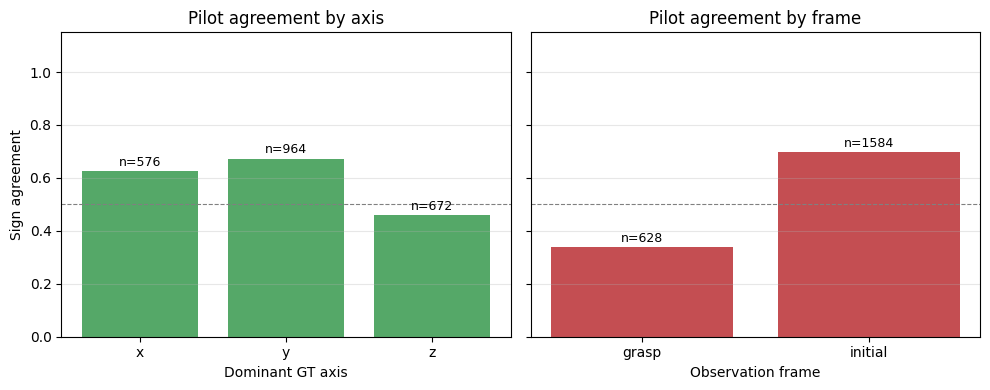

In [7]:
if pilot.empty:
    print('No pilot rows (no ground-truth vectors above MIN_GT_NORM).')
else:
    by_axis = pilot.groupby('dominant_axis')['agree'].agg(['mean', 'count']).reindex(
        [a for a in 'xyz' if a in set(pilot['dominant_axis'])])
    by_frame = pilot.groupby('frame')['agree'].agg(['mean', 'count'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    axes[0].bar(by_axis.index.astype(str), by_axis['mean'], color='#55A868')
    for i, (m, c) in enumerate(zip(by_axis['mean'], by_axis['count'])):
        axes[0].text(i, m + 0.02, f'n={int(c)}', ha='center', fontsize=9)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_ylabel('Sign agreement')
    axes[0].set_xlabel('Dominant GT axis')
    axes[0].set_title('Pilot agreement by axis')
    axes[0].axhline(0.5, color='grey', ls='--', lw=0.8)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(by_frame.index.astype(str), by_frame['mean'], color='#C44E52')
    for i, (m, c) in enumerate(zip(by_frame['mean'], by_frame['count'])):
        axes[1].text(i, m + 0.02, f'n={int(c)}', ha='center', fontsize=9)
    axes[1].set_xlabel('Observation frame')
    axes[1].set_title('Pilot agreement by frame')
    axes[1].axhline(0.5, color='grey', ls='--', lw=0.8)
    axes[1].grid(axis='y', alpha=0.3)

    fig.tight_layout()
    out = os.path.join(FIGS_DIR, '02_pilot_sign_agreement.png')
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('wrote', out)
    print(by_axis)
    print(by_frame)
    plt.show()


## 8. Stratified headline summary

Per-stratum counts, descriptive sign-flip rate, Wilcoxon signed-rank statistic
on `dx_A - dx_B`, and median paired difference. Strata are never pooled into a
single headline number.


wrote /content/drive/MyDrive/openvla_cache/results_figs/03_stratified_headline.png


,stratum_key,stratum,n,sign_flip_rate,W,p,median_diff
0,primary_referent,referent_selection & feasible (initial),7,0.000000,5.0,1.000000,0.0
1,placement_grasp,placement_relation (grasp),316,0.246835,9606.5,0.263441,0.0
2,placement_initial,"placement_relation (initial, expected null)",409,0.149144,9656.0,0.002430,0.0
3,referent_other,referent_selection infeasible/unreviewed,381,0.230971,12496.5,0.375289,0.0
4,other,other,0,NaN,NaN,NaN,NaN


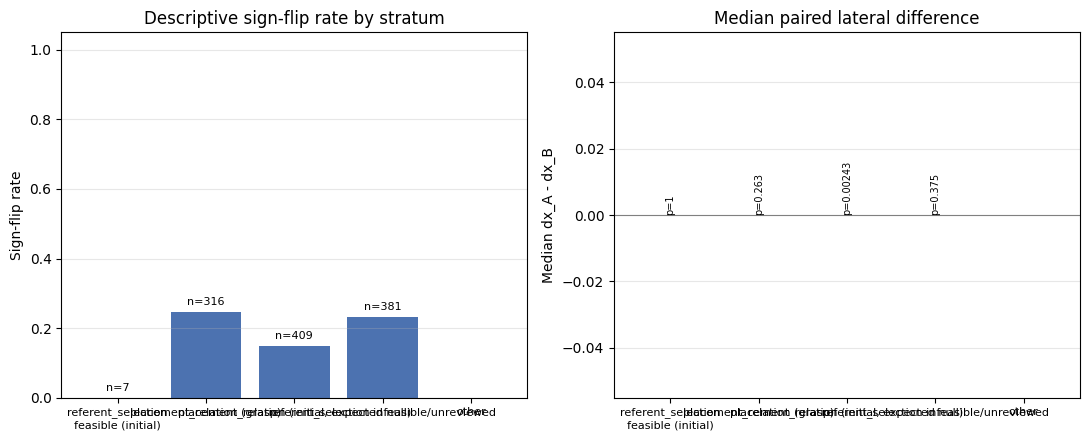

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_sum = summary.copy()
labels = [s.replace(' & ', '\n') for s in plot_sum['stratum']]
x = np.arange(len(plot_sum))

axes[0].bar(x, plot_sum['sign_flip_rate'].fillna(0), color='#4C72B0')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Sign-flip rate')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Descriptive sign-flip rate by stratum')
for i, (r, n) in enumerate(zip(plot_sum['sign_flip_rate'], plot_sum['n'])):
    if pd.notna(r):
        axes[0].text(i, r + 0.02, f'n={int(n)}', ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, plot_sum['median_diff'].fillna(0), color='#8172B3')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Median dx_A - dx_B')
axes[1].axhline(0, color='grey', lw=0.8)
axes[1].set_title('Median paired lateral difference')
for i, (p, n) in enumerate(zip(plot_sum['p'], plot_sum['n'])):
    if pd.notna(p):
        axes[1].text(i, 0, f'p={p:.3g}', ha='center', va='bottom', fontsize=7,
                     rotation=90)
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
out = os.path.join(FIGS_DIR, '03_stratified_headline.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
print('wrote', out)
display(summary)
plt.show()


## 9. Primary-stratum difference distribution

Histogram of the paired lateral difference for the primary analysis stratum
(`referent_selection`, feasible on both sides, initial frame). The median is
annotated on the plot.


wrote /content/drive/MyDrive/openvla_cache/results_figs/04_primary_diff_distribution.png


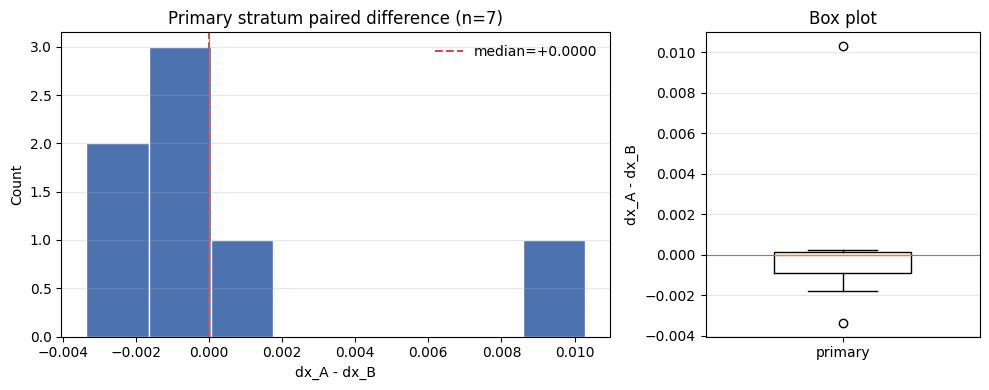

In [9]:
primary = df[stratum_mask('primary_referent')]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})

if primary.empty:
    axes[0].text(0.5, 0.5, 'No primary-stratum pairs', ha='center', va='center')
    axes[1].axis('off')
else:
    diffs = primary['diff'].to_numpy()
    med = float(np.median(diffs))
    axes[0].hist(diffs, bins=min(30, max(8, len(diffs) // 3)),
                 color='#4C72B0', edgecolor='white')
    axes[0].axvline(med, color='#C44E52', ls='--', lw=1.5, label=f'median={med:+.4f}')
    axes[0].axvline(0, color='grey', lw=0.8)
    axes[0].set_xlabel('dx_A - dx_B')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Primary stratum paired difference (n={len(primary)})')
    axes[0].legend(frameon=False)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].boxplot(diffs, vert=True, widths=0.5)
    axes[1].axhline(0, color='grey', lw=0.8)
    axes[1].set_ylabel('dx_A - dx_B')
    axes[1].set_xticks([1])
    axes[1].set_xticklabels(['primary'])
    axes[1].set_title('Box plot')
    axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
out = os.path.join(FIGS_DIR, '04_primary_diff_distribution.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
print('wrote', out)
plt.show()


## 10. Sign-flip rate by spatial term

Descriptive breakdown within the primary stratum (and, when present, the
placement grasp stratum). Small cells are noisy; treat rates as exploratory.


wrote /content/drive/MyDrive/openvla_cache/results_figs/05_sign_flip_by_term_primary.png


,sign_flip_rate,n
spatial_term,,
left,0.0,1
right,0.0,1
front,0.0,5


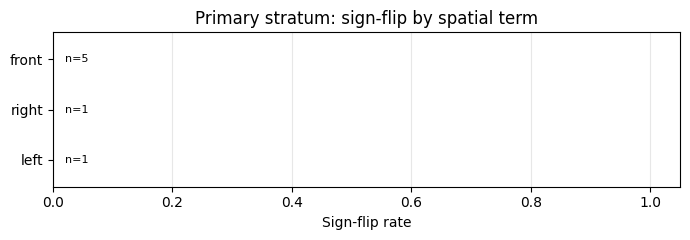

wrote /content/drive/MyDrive/openvla_cache/results_figs/05_sign_flip_by_term_placement_grasp.png


,sign_flip_rate,n
spatial_term,,
back,0.000000,1
bottom,0.000000,1
top,0.161290,62
right,0.337662,77
in front of,0.209877,81
left,0.265957,94


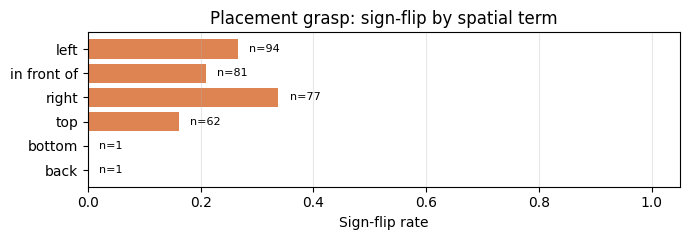

In [10]:
def flip_by_term(sub, title, fname):
    if sub.empty:
        print(f'{title}: empty')
        return
    g = (sub.groupby('spatial_term')['sign_flip']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'sign_flip_rate', 'count': 'n'})
            .sort_values('n', ascending=True))
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.35 * len(g))))
    ax.barh(g.index.astype(str), g['sign_flip_rate'], color='#DD8452')
    for y, (r, n) in enumerate(zip(g['sign_flip_rate'], g['n'])):
        ax.text(min(r + 0.02, 0.98), y, f'n={int(n)}', va='center', fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Sign-flip rate')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    out = os.path.join(FIGS_DIR, fname)
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('wrote', out)
    display(g)
    plt.show()


flip_by_term(df[stratum_mask('primary_referent')],
             'Primary stratum: sign-flip by spatial term',
             '05_sign_flip_by_term_primary.png')
flip_by_term(df[stratum_mask('placement_grasp')],
             'Placement grasp: sign-flip by spatial term',
             '05_sign_flip_by_term_placement_grasp.png')


## 11. Predicted dx_A versus dx_B

Each point is one contrastive pair. Points in opposite-sign quadrants are
sign flips; the diagonal is same-sign predictions. Colour encodes the analysis
stratum.


wrote /content/drive/MyDrive/openvla_cache/results_figs/06_dx_a_vs_dx_b.png


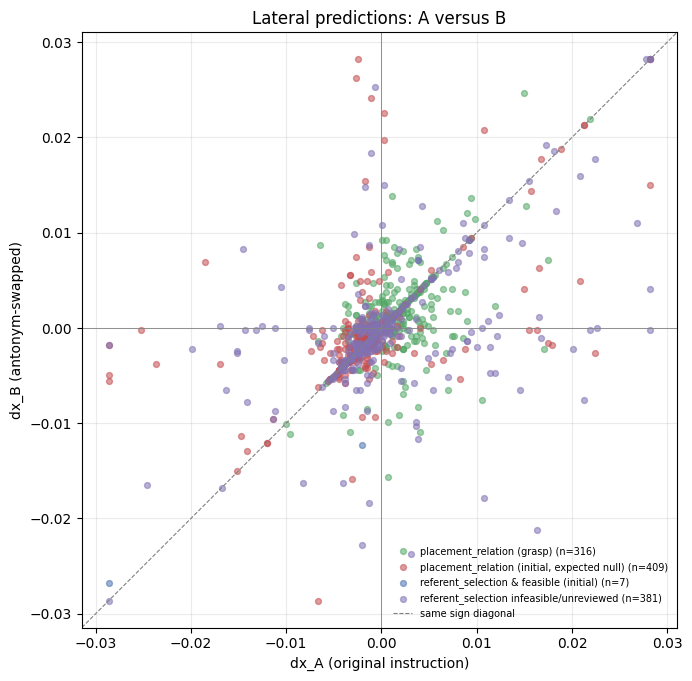

In [11]:
# Assign a single stratum label per row (first matching STRATA entry wins).
df_plot = df.copy()
df_plot['stratum'] = 'unassigned'
for key, label in STRATA:
    m = stratum_mask(key)
    df_plot.loc[m, 'stratum'] = label

fig, ax = plt.subplots(figsize=(7, 7))
cmap = {
    'referent_selection & feasible (initial)': '#4C72B0',
    'placement_relation (grasp)': '#55A868',
    'placement_relation (initial, expected null)': '#C44E52',
    'referent_selection infeasible/unreviewed': '#8172B3',
    'other': '#CCB974',
    'unassigned': '#7F7F7F',
}
lims = []
for label, sub in df_plot.groupby('stratum'):
    if sub.empty:
        continue
    ax.scatter(sub['lat_a'], sub['lat_b'], s=18, alpha=0.55,
               c=cmap.get(label, '#7F7F7F'), label=f'{label} (n={len(sub)})')
    lims.extend(sub['lat_a'].tolist())
    lims.extend(sub['lat_b'].tolist())

if lims:
    lo, hi = float(np.min(lims)), float(np.max(lims))
    pad = 0.05 * (hi - lo + 1e-9)
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], color='grey', ls='--', lw=0.8, label='same sign diagonal')
    ax.axhline(0, color='grey', lw=0.6)
    ax.axvline(0, color='grey', lw=0.6)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

ax.set_xlabel('dx_A (original instruction)')
ax.set_ylabel('dx_B (antonym-swapped)')
ax.set_title('Lateral predictions: A versus B')
ax.set_aspect('equal', adjustable='box')
ax.legend(fontsize=7, loc='best', frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
out = os.path.join(FIGS_DIR, '06_dx_a_vs_dx_b.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
print('wrote', out)
plt.show()


## 12. Scene gallery

Cached BridgeData frames for a small curated set from the primary stratum:
examples with a lateral sign flip and examples without. Each panel shows the
observation the model saw, both instructions, and the predicted `dx` values.


wrote /content/drive/MyDrive/openvla_cache/results_figs/07_scene_gallery_primary.png


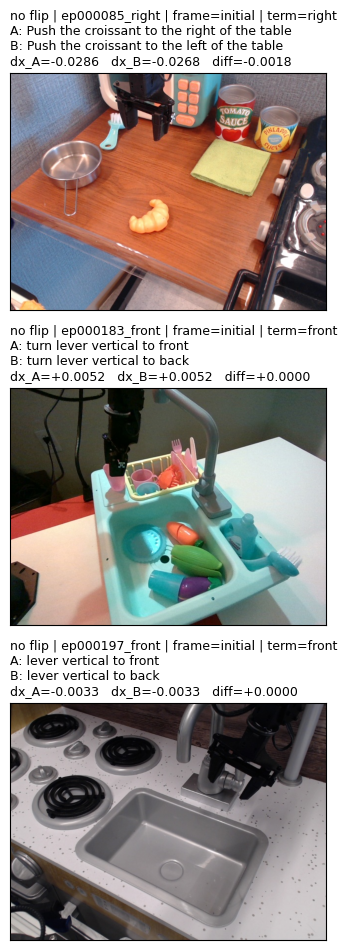

In [12]:
from PIL import Image

GALLERY_N = 3  # examples per flip / no-flip group


def resolve_image(rel_path):
    """Resolve a pairs.json image_path against the Drive cache."""
    if not rel_path:
        return None
    candidates = [
        os.path.join(CACHE_DIR, rel_path),
        os.path.join(CACHE_DIR, 'frames', os.path.basename(rel_path)),
        rel_path,
    ]
    for c in candidates:
        if os.path.isfile(c):
            return c
    return None


primary = df[stratum_mask('primary_referent')]
primary_pairs = []
for _, row in primary.iterrows():
    p = pair_lookup.get((row['pair_id'], row['frame']))
    if p is None:
        continue
    primary_pairs.append((row, p))

flip_ex = [t for t in primary_pairs if t[0]['sign_flip']][:GALLERY_N]
noflip_ex = [t for t in primary_pairs if not t[0]['sign_flip']][:GALLERY_N]
gallery = [('sign flip', t) for t in flip_ex] + [('no flip', t) for t in noflip_ex]

if not gallery:
    print('No primary-stratum pairs available for the gallery.')
else:
    n = len(gallery)
    fig, axes = plt.subplots(n, 1, figsize=(9, 3.2 * n))
    if n == 1:
        axes = [axes]
    for ax, (tag, (row, p)) in zip(axes, gallery):
        img_path = resolve_image(p.get('image_path'))
        if img_path is not None:
            ax.imshow(Image.open(img_path))
        else:
            ax.text(0.5, 0.5, 'image missing', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_facecolor('#eee')
        ax.set_xticks([])
        ax.set_yticks([])
        title = (f"{tag} | {p['pair_id']} | frame={p['frame']} | "
                 f"term={p.get('spatial_term', '')}\n"
                 f"A: {p['instr_a']}\n"
                 f"B: {p['instr_b']}\n"
                 f"dx_A={row['lat_a']:+.4f}   dx_B={row['lat_b']:+.4f}   "
                 f"diff={row['diff']:+.4f}")
        ax.set_title(title, fontsize=9, loc='left')
    fig.tight_layout()
    out = os.path.join(FIGS_DIR, '07_scene_gallery_primary.png')
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('wrote', out)
    plt.show()


## 13. Figure index

All PNGs written in this session under `results_figs/`.


In [13]:
written = sorted(f for f in os.listdir(FIGS_DIR) if f.endswith('.png'))
print(f'{len(written)} figures in {FIGS_DIR}:')
for f in written:
    print(' ', f)


8 figures in /content/drive/MyDrive/openvla_cache/results_figs:
  01_inventory_stratum_sizes.png
  02_pilot_sign_agreement.png
  03_stratified_headline.png
  04_primary_diff_distribution.png
  05_sign_flip_by_term_placement_grasp.png
  05_sign_flip_by_term_primary.png
  06_dx_a_vs_dx_b.png
  07_scene_gallery_primary.png
